# EDA · Financial PhraseBank
### TFM · Roboadvisor personalizado — Módulo M1 (Perfilado NLP)


**Dataset:** `financial_phrasebank.csv` — Malo, Sinha, Korhonen, Wallenius & Takala (2014)

---

Este notebook no es un análisis genérico del Financial PhraseBank. Su objetivo es responder a las preguntas que necesita el proyecto antes de integrar FinBERT en el pipeline de perfilado del inversor:

1. **¿Qué subconjunto del dataset usar como *gold standard*** para validar FinBERT en    modo zero-shot?
2. **¿Qué desbalance de clases** hay que asumir y cómo afecta a la métrica de éxito    declarada en la Fase 0 (*accuracy ≥ 85%*)?
3. **¿Hay fugas de información** (mismas frases en distintos niveles de agreement) que    contaminen la evaluación?
4. **¿Las longitudes de frase** son compatibles con el límite de tokens de FinBERT (512)?
5. **¿Qué baseline realista** de accuracy debe batir el sistema NLP?


## 1. Introducción y contexto

### 1.1 Qué es el Financial PhraseBank

Es el **dataset de referencia** para análisis de sentimiento financiero en inglés. Consiste en frases extraídas de noticias financieras y notas de prensa del mercado OMX Helsinki (~2008–2013), anotadas manualmente por 16 anotadores (estudiantes y profesores de finanzas) con una de tres etiquetas: `positive`, `neutral`, `negative` desde la perspectiva de un inversor.

La particularidad clave del dataset es que **los autores publican cuatro versiones** según el nivel de acuerdo entre anotadores: 50%, 66%, 75% y 100% (*allagree*). El CSV que vamos a explorar las **concatena todas**, por lo que el primer riesgo a verificar es si una misma frase aparece en varias filas.

### 1.2 Por qué importa para M1

La arquitectura declarada en este proyecto contempla el uso de **FinBERT (ProsusAI/finbert)** en modo pre-entrenado sobre las respuestas abiertas del cuestionario traducidas al inglés. FinBERT fue entrenado precisamente sobre este dataset, por lo que:

- No podemos usar Financial PhraseBank como *training set* (sería data leakage puro: ya está dentro del modelo).
- **Sí** podemos usarlo como *test set* para reportar la accuracy de FinBERT en su dominio nativo. Este número actuará de **cota superior realista** de lo que cabe   esperar sobre nuestras 30 personas sintéticas.

### 1.3 Preguntas que guían el EDA

| # | Pregunta | Sección |
|---|---|---|
| Q1 | ¿Qué tamaño, dtypes y memoria tiene el dataset? | 3 |
| Q2 | ¿Hay frases duplicadas entre niveles de agreement? | 4 |
| Q3 | ¿Cuál es el desbalance de clases en cada subconjunto? | 5 |
| Q4 | ¿Qué longitud de frase tenemos? ¿Cabe en 512 tokens de BERT? | 5 |
| Q5 | ¿El nivel de agreement correlaciona con la clase (p.ej. ¿las neutras son más fáciles de consensuar)? | 6, 8 |
| Q6 | ¿Qué frases son atípicas (muy largas, muy cortas, con mucho ruido numérico)? | 7 |
| Q7 | ¿Qué baseline de accuracy por clase mayoritaria y qué subset usar como gold? | 9 |


## 2. Carga de datos

El archivo es CSV plano en UTF-8 con tres columnas y separador coma. No hay cabecera ambigua ni encoding problemático, así que la carga es directa con `pd.read_csv`.


In [1]:
# --- roboadvisor_paths bootstrap (auto-inserted) ---
import sys
from pathlib import Path as _P

_repo = _P.cwd().resolve()
while _repo != _repo.parent and not (_repo / "src" / "roboadvisor_paths.py").exists():
    _repo = _repo.parent
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

import roboadvisor_paths as PATHS  # noqa: E402
PATHS.ensure_dirs()


In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

DATA_PATH = PATHS.PHRASEBANK_CSV
AGREEMENT_ORDER = ['50agree', '66agree', '75agree', 'allagree']
LABEL_ORDER = ['negative', 'neutral', 'positive']

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Filas × columnas: {df.shape[0]:,} × {df.shape[1]}')
df.head(5)

Filas × columnas: 14,780 × 3


,sentence,label,agreement_level
0,"According to Gran , the company has no plans to move all production to Russia , although that is where the company i...",neutral,50agree
1,"Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies work...",neutral,50agree
2,The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; con...,negative,50agree
3,With the new production plant the company would increase its capacity to meet the expected increase in demand and wo...,positive,50agree
4,"According to the company 's updated strategy for the years 2009-2012 , Basware targets a long-term net sales growth ...",positive,50agree


Tres columnas tal como se documenta en la tarjeta del dataset:

- `sentence`: el texto anotado.
- `label`: clase de sentimiento — `positive` / `neutral` / `negative`.
- `agreement_level`: umbral de acuerdo entre anotadores — `50agree` / `66agree` / `75agree` / `allagree`.

Ordenamos `agreement_level` y `label` como variables **categóricas ordenadas**. Para `agreement_level` el orden es semánticamente natural (de menor a mayor consenso); para `label` lo fijamos por convención para que los gráficos sean reproducibles.

In [4]:
df['agreement_level'] = pd.Categorical(
    df['agreement_level'], categories=AGREEMENT_ORDER, ordered=True
)
df['label'] = pd.Categorical(df['label'], categories=LABEL_ORDER, ordered=False)
df.dtypes

sentence             object
label              category
agreement_level    category
dtype: object

## 3. Resumen general

Vista rápida del tamaño, tipos, memoria y estadísticas de alto nivel antes de entrar en calidad de datos.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14780 entries, 0 to 14779
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sentence         14780 non-null  object  
 1   label            14780 non-null  category
 2   agreement_level  14780 non-null  category
dtypes: category(2), object(1)
memory usage: 144.8+ KB


In [6]:
df.describe(include='all').T

,count,unique,top,freq
sentence,14780,4838,The issuer is solely responsible for the content of this announcement .,8
label,14780,3,neutral,8951
agreement_level,14780,4,50agree,4846


In [7]:
mem_mb = df.memory_usage(deep=True).sum() / 1024**2
print(f'Uso de memoria: {mem_mb:.2f} MB')
print(f'Filas: {len(df):,}')
print(f'Columnas: {df.shape[1]}')
print(f'Frases únicas: {df["sentence"].nunique():,}')
print(f'Duplicados exactos (las 3 columnas): {df.duplicated().sum()}')

Uso de memoria: 2.50 MB
Filas: 14,780
Columnas: 3
Frases únicas: 4,838
Duplicados exactos (las 3 columnas): 22


### Hallazgos rápidos

- El dataset pesa menos de 5 MB → cabe en memoria sin problemas, no hace falta   `dask` ni `duckdb`.
- **Atención**: `df.shape[0]` (~14.780) **≠** `nunique(sentence)` (~4.838). Esto apunta   a la estructura anidada que se investiga en la siguiente sección.
- Hay duplicados exactos (fila completa repetida), marginales pero hay que limpiarlos.

## 4. Calidad de datos

Aquí es donde se esconden los riesgos metodológicos. Chequeamos nulos, duplicados y lo más importante: **la estructura anidada por nivel de agreement**.

### 4.1 Nulos

In [8]:
nulls = df.isna().sum().to_frame('nulos')
nulls['pct'] = (nulls['nulos'] / len(df) * 100).round(2)
nulls

,nulos,pct
sentence,0,0.000
label,0,0.000
agreement_level,0,0.000


Sin nulos. No requiere imputación.

### 4.2 Duplicados exactos y por frase

In [9]:
dup_full = df.duplicated().sum()
dup_sentence = df.duplicated(subset=['sentence']).sum()
dup_sentence_label = df.duplicated(subset=['sentence', 'label']).sum()

resumen_dup = pd.DataFrame({
    'criterio': [
        'Fila exacta (sentence + label + agreement)',
        'Misma frase + misma etiqueta (distinto agreement)',
        'Misma frase (cualquier etiqueta)',
    ],
    'duplicados': [dup_full, dup_sentence_label, dup_sentence],
    'pct_sobre_total': [
        f'{dup_full / len(df) * 100:.2f}%',
        f'{dup_sentence_label / len(df) * 100:.2f}%',
        f'{dup_sentence / len(df) * 100:.2f}%',
    ],
})
resumen_dup

,criterio,duplicados,pct_sobre_total
0,Fila exacta (sentence + label + agreement),22,0.15%
1,Misma frase + misma etiqueta (distinto agreement),9940,67.25%
2,Misma frase (cualquier etiqueta),9942,67.27%


### 4.3 Hallazgo crítico: estructura anidada por nivel de agreement

El ~67% de las filas son la misma frase repetida en distintos niveles de agreement. Esto no es un error del CSV: es la forma original en la que Malo et al. (2014) distribuyeron el dataset. El Financial PhraseBank se publica en **cuatro ficheros** (`Sentences_50Agree.txt`, `Sentences_66Agree.txt`, `Sentences_75Agree.txt`, `Sentences_AllAgree.txt`) donde **cada uno contiene un subconjunto del anterior**.

Verificamos empíricamente esta inclusión:

In [10]:
def frases_en(nivel: str) -> set[str]:
    """Devuelve el conjunto de frases etiquetadas en el nivel de agreement dado."""
    return set(df.loc[df['agreement_level'] == nivel, 'sentence'])

s50, s66, s75, sall = (frases_en(n) for n in AGREEMENT_ORDER)

inclusion = pd.DataFrame({
    'nivel': AGREEMENT_ORDER,
    'frases_unicas': [len(s50), len(s66), len(s75), len(sall)],
    'subset_del_anterior': [
        '—',
        f'{s66.issubset(s50)}',
        f'{s75.issubset(s66)}',
        f'{sall.issubset(s75)}',
    ],
})
inclusion

,nivel,frases_unicas,subset_del_anterior
0,50agree,4838,—
1,66agree,4211,True
2,75agree,3448,True
3,allagree,2259,True


Confirmado: **`allagree ⊂ 75agree ⊂ 66agree ⊂ 50agree`**. Las 2.259 frases de `allagree` también están en los otros tres niveles, de ahí las 3× duplicaciones.

**Implicación directa para el TFM (M1):**

> Si evaluáramos FinBERT sobre `df` completo, estaríamos contando la misma frase > hasta cuatro veces. El número que reportemos como accuracy sería artificial. > En la memoria hay que declarar que **la unidad de análisis es la frase única**, no > la fila del CSV, y justificar qué subset se elige como gold standard (recomendación > en S9).

### 4.4 Inconsistencias de etiquetado entre niveles

In [11]:
# ¿Alguna frase tiene distinta etiqueta en distintos niveles de agreement?
labels_por_frase = df.groupby('sentence')['label'].nunique()
inconsistentes = labels_por_frase[labels_por_frase > 1]
print(f'Frases con etiquetas inconsistentes entre niveles: {len(inconsistentes)}')

if len(inconsistentes) > 0:
    df_inc = df[df['sentence'].isin(inconsistentes.index)].sort_values('sentence')
    display(df_inc)

Frases con etiquetas inconsistentes entre niveles: 2


,sentence,label,agreement_level
78,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sells stake in Morning Digital Design Oy Finnish IT company TJ Group Plc ...,neutral,50agree
79,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sells stake in Morning Digital Design Oy Finnish IT company TJ Group Plc ...,positive,50agree
4914,TELECOMWORLDWIRE-7 April 2006-TJ Group Plc sells stake in Morning Digital Design Oy Finnish IT company TJ Group Plc ...,positive,66agree
788,The Group 's business is balanced by its broad portfolio of sports and presence in all major markets .,positive,50agree
789,The Group 's business is balanced by its broad portfolio of sports and presence in all major markets .,neutral,50agree
5540,The Group 's business is balanced by its broad portfolio of sports and presence in all major markets .,positive,66agree


Solo 2 frases tienen etiquetas distintas en niveles distintos. Probablemente son casos borderline que, al subir el umbral de acuerdo, cambiaron de clase ganadora por un voto. Son anécdotas, no un problema sistémico. Las podemos resolver quedándonos con la etiqueta del nivel más restrictivo (máximo consenso) cuando deduplicamos.

### 4.5 Cardinalidad y rangos

In [12]:
print('Cardinalidad de categóricas:')
for col in ['label', 'agreement_level']:
    print(f'  {col}: {df[col].nunique()} valores → {list(df[col].unique())}')

print(f'\nLongitud de frase: min={df["sentence"].str.len().min()}, '
      f'max={df["sentence"].str.len().max()}')

Cardinalidad de categóricas:
  label: 3 valores → ['neutral', 'negative', 'positive']
  agreement_level: 4 valores → ['50agree', '66agree', '75agree', 'allagree']

Longitud de frase: min=9, max=315


### Conclusiones de calidad

1. **Sin nulos** → no requiere imputación.
2. **22 duplicados exactos** → eliminar con `drop_duplicates()`, coste cero.
3. **Estructura anidada** → es el hallazgo más importante. Obliga a deduplicar por    `sentence` antes de cualquier evaluación de modelo.
4. **Inconsistencias mínimas** (2 frases) → resolver quedándose con la etiqueta del    nivel de mayor agreement disponible.
5. **Longitudes** entre 9 y 315 caracteres → todas entran en el límite de 512 tokens    de FinBERT sin truncado (veremos la distribución en §5).


## 5. Análisis univariado

Una vez entendida la estructura del CSV, creamos un **DataFrame deduplicado** con la etiqueta del máximo nivel de agreement disponible por frase. Todo el análisis estadístico a partir de aquí se hace sobre este dataframe limpio.

In [13]:
def deduplicar_por_frase(df_in: pd.DataFrame) -> pd.DataFrame:
    """Devuelve una fila por frase, con la etiqueta y el agreement máximo observado.

    En caso de frases con etiquetas distintas en distintos niveles, se conserva la del
    nivel de mayor agreement (mayor consenso entre anotadores), criterio coherente con
    la literatura (Malo et al. 2014).
    """
    df_sorted = df_in.sort_values('agreement_level', ascending=False)
    return df_sorted.drop_duplicates(subset=['sentence'], keep='first').reset_index(drop=True)


df_unique = deduplicar_por_frase(df)
print(f'DataFrame original: {len(df):,} filas')
print(f'DataFrame deduplicado: {len(df_unique):,} frases únicas')
df_unique.head(3)

DataFrame original: 14,780 filas
DataFrame deduplicado: 4,838 frases únicas


,sentence,label,agreement_level
0,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",negative,allagree
1,"Mika Stahlberg , VP F-Secure Labs , said , `` We are excited and proud that F-Secure has been recognized by AV-Compa...",positive,allagree
2,Any investment or investment activity to which this communication relates is only available to relevant persons and ...,neutral,allagree


### 5.1 Distribución de la variable objetivo (`label`)

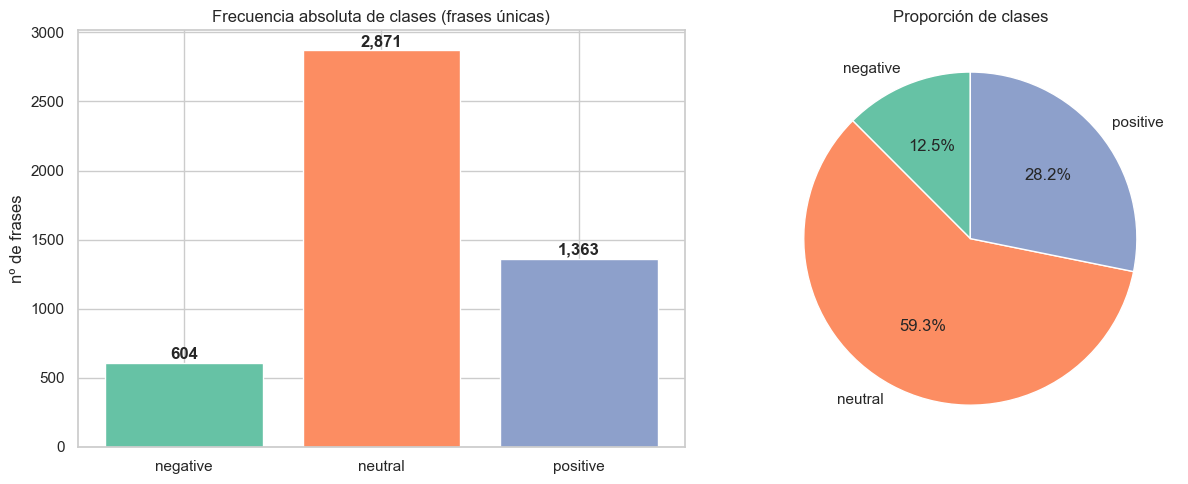

Baseline naive (clase mayoritaria): 59.34%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Conteo absoluto
counts = df_unique['label'].value_counts().reindex(LABEL_ORDER)
axes[0].bar(counts.index, counts.values, color=sns.color_palette('Set2', 3))
axes[0].set_title('Frecuencia absoluta de clases (frases únicas)')
axes[0].set_ylabel('nº de frases')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Proporción
props = counts / counts.sum() * 100
axes[1].pie(props.values, labels=props.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', 3), startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.show()

print(f'Baseline naive (clase mayoritaria): {props.max():.2f}%')

**Desbalance notable**:

- `neutral` domina (~60%), `positive` ~28%, `negative` ~12%.
- Un clasificador que prediga siempre *neutral* ya acierta el ~60%. Éste es el   **baseline** que FinBERT debe batir ampliamente.
- Este desbalance tiene una consecuencia inmediata para M1 del TFM: la métrica de   éxito *accuracy ≥ 85%* declarada en la Fase 0 está razonablemente calibrada sobre   el dataset nativo de FinBERT (el paper de ProsusAI reporta ~86% en *allagree*), pero   **conviene complementarla con F1-macro** porque la accuracy sobre la clase   negativa es la más difícil y la más relevante financieramente (falsos positivos de   optimismo son peligrosos).

### 5.2 Distribución por nivel de agreement

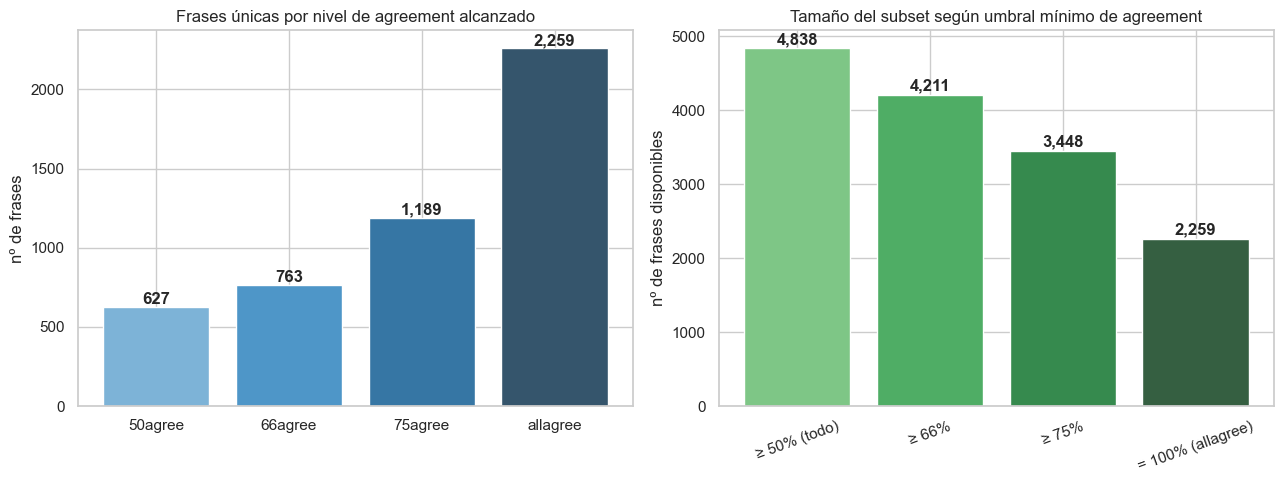

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

agreement_counts = (df_unique.groupby('agreement_level', observed=True)
                    .size().reindex(AGREEMENT_ORDER).fillna(0).astype(int))

axes[0].bar(agreement_counts.index, agreement_counts.values,
            color=sns.color_palette('Blues_d', 4))
axes[0].set_title('Frases únicas por nivel de agreement alcanzado')
axes[0].set_ylabel('nº de frases')
for i, v in enumerate(agreement_counts.values):
    axes[0].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

# Acumulado descendente: cuántas frases tenemos si exigimos agreement >= X
cum = pd.Series({
    '≥ 50% (todo)': df_unique.shape[0],
    '≥ 66%': (df_unique['agreement_level'].isin(['66agree', '75agree', 'allagree'])).sum(),
    '≥ 75%': (df_unique['agreement_level'].isin(['75agree', 'allagree'])).sum(),
    '= 100% (allagree)': (df_unique['agreement_level'] == 'allagree').sum(),
})
axes[1].bar(cum.index, cum.values, color=sns.color_palette('Greens_d', 4))
axes[1].set_title('Tamaño del subset según umbral mínimo de agreement')
axes[1].set_ylabel('nº de frases disponibles')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(cum.values):
    axes[1].text(i, v + 60, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

Lectura clave para M1:

- Si usamos **solo `allagree`** (consenso del 100%) tenemos **2.259 frases**,   suficientes para una evaluación robusta y con máxima fiabilidad de etiqueta →   recomendación por defecto.
- Si usamos **`≥ 75agree`** subimos a **3.448 frases** con un leve coste en ruido   de etiquetado.
- `50agree` añade frases borderline donde los propios anotadores discrepan.   Útiles para analizar casos difíciles pero **no recomendables como gold standard**.

### 5.3 Longitud de las frases

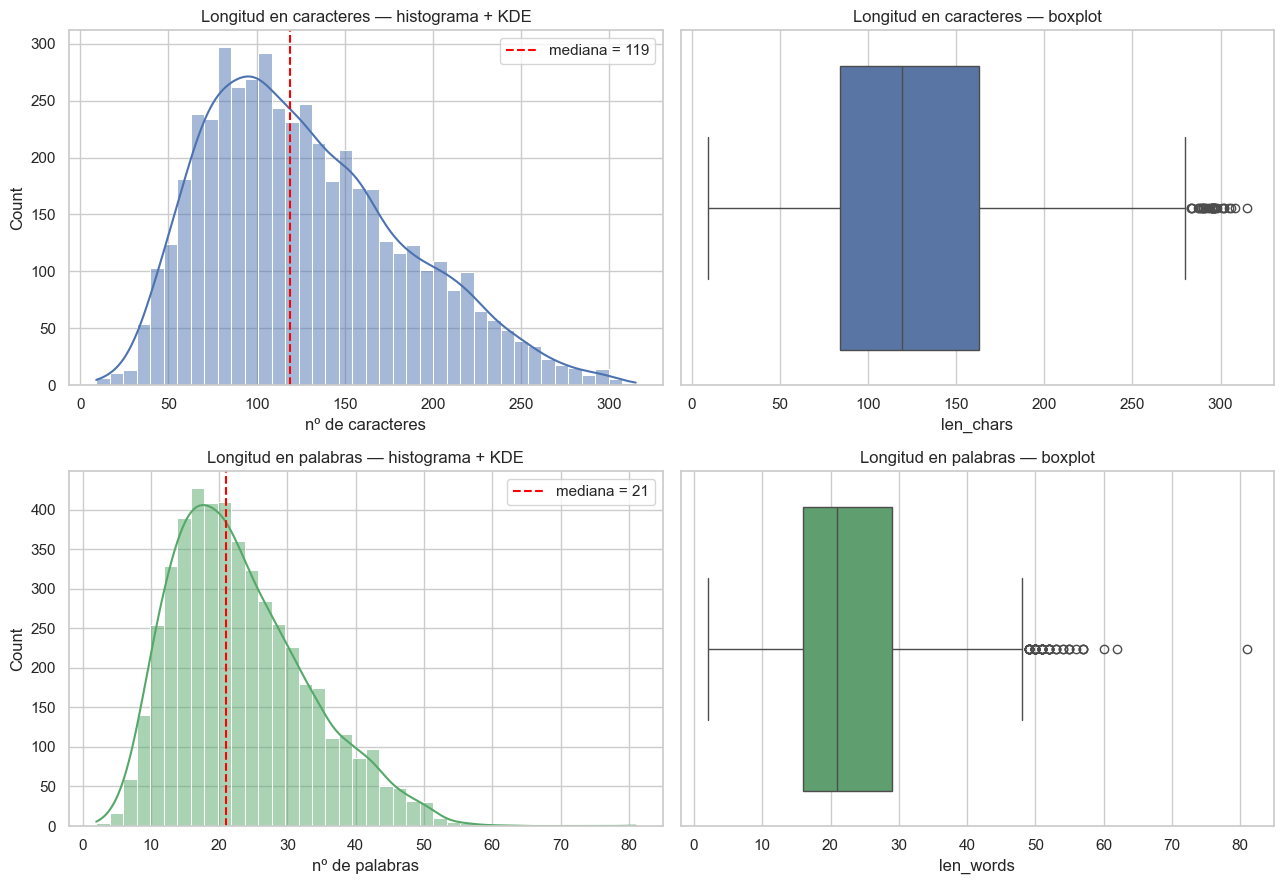

In [16]:
df_unique = df_unique.assign(
    len_chars=df_unique['sentence'].str.len(),
    len_words=df_unique['sentence'].str.split().str.len(),
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.histplot(df_unique['len_chars'], bins=40, kde=True, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Longitud en caracteres — histograma + KDE')
axes[0, 0].set_xlabel('nº de caracteres')
axes[0, 0].axvline(df_unique['len_chars'].median(), color='red',
                   linestyle='--', label=f"mediana = {df_unique['len_chars'].median():.0f}")
axes[0, 0].legend()

sns.boxplot(x=df_unique['len_chars'], ax=axes[0, 1], color='#4C72B0')
axes[0, 1].set_title('Longitud en caracteres — boxplot')

sns.histplot(df_unique['len_words'], bins=40, kde=True, ax=axes[1, 0], color='#55A868')
axes[1, 0].set_title('Longitud en palabras — histograma + KDE')
axes[1, 0].set_xlabel('nº de palabras')
axes[1, 0].axvline(df_unique['len_words'].median(), color='red',
                   linestyle='--', label=f"mediana = {df_unique['len_words'].median():.0f}")
axes[1, 0].legend()

sns.boxplot(x=df_unique['len_words'], ax=axes[1, 1], color='#55A868')
axes[1, 1].set_title('Longitud en palabras — boxplot')

plt.tight_layout()
plt.show()

In [17]:
def resumen_tendencia(s: pd.Series) -> pd.Series:
    """Devuelve media, mediana, desviación, IQR y MAD en una fila."""
    q1, q3 = s.quantile([0.25, 0.75])
    return pd.Series({
        'media': s.mean(),
        'mediana': s.median(),
        'std': s.std(),
        'iqr': q3 - q1,
        'mad': stats.median_abs_deviation(s),
        'min': s.min(),
        'max': s.max(),
    })

pd.DataFrame({
    'len_chars': resumen_tendencia(df_unique['len_chars']),
    'len_words': resumen_tendencia(df_unique['len_words']),
}).round(2)

,len_chars,len_words
media,128.060,23.090
mediana,119.000,21.000
std,56.410,9.940
iqr,79.000,13.000
mad,39.000,7.000
min,9.000,2.000
max,315.000,81.000


- Distribuciones con **sesgo a la derecha** (cola larga): mediana < media en ambas.
- El 75% de las frases tienen ≤ 29 palabras. La frase más larga (~80 palabras, ~315 chars)   sigue entrando holgadamente en los **512 tokens** del tokenizer de FinBERT.   **No hace falta estrategia de truncado ni de chunking** para M1.
- No hay frases vacías; la mínima tiene 2 palabras (p.ej. `"EPS dropped."`).

## 6. Análisis bivariado

Nos interesan tres relaciones:

1. `label` × `agreement_level` — ¿qué clases son más fáciles de consensuar?
2. `len_words` × `label` — ¿las frases de cada clase tienen longitudes distintas?
3. `len_words` × `agreement_level` — ¿las frases largas son más polémicas?


### 6.1 Clase × Agreement

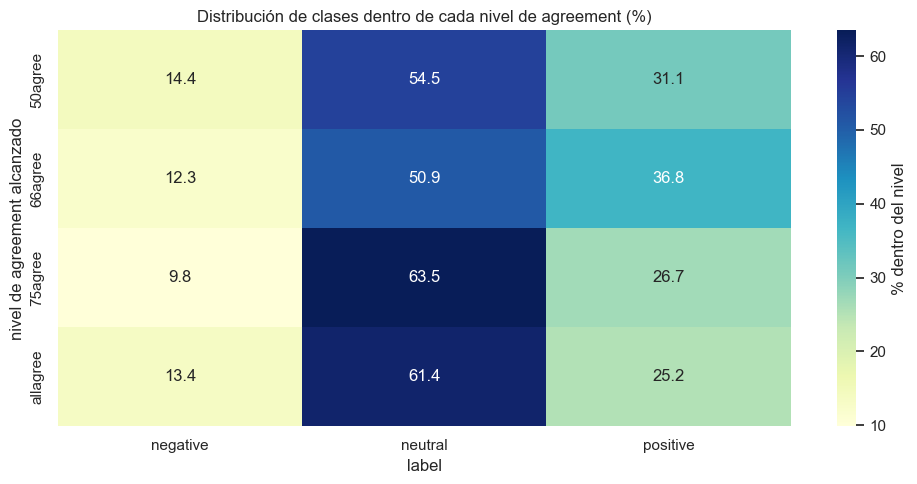

label,negative,neutral,positive
agreement_level,,,
50agree,14.400,54.500,31.100
66agree,12.300,50.900,36.800
75agree,9.800,63.500,26.700
allagree,13.400,61.400,25.200


In [18]:
ct = pd.crosstab(
    df_unique['agreement_level'], df_unique['label'],
    normalize='index'
).reindex(AGREEMENT_ORDER)[LABEL_ORDER] * 100

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% dentro del nivel'}, ax=ax)
ax.set_title('Distribución de clases dentro de cada nivel de agreement (%)')
ax.set_ylabel('nivel de agreement alcanzado')
plt.tight_layout()
plt.show()

ct.round(1)

El desbalance de clases es **relativamente estable** a lo largo de los niveles de agreement: `neutral` siempre ronda el 60%, `positive` 25–28% y `negative` 12–13%. Esto sugiere que el nivel de consenso no depende fuertemente del tono. Lo validaremos formalmente con un test χ² en §8.

### 6.2 Longitud × clase

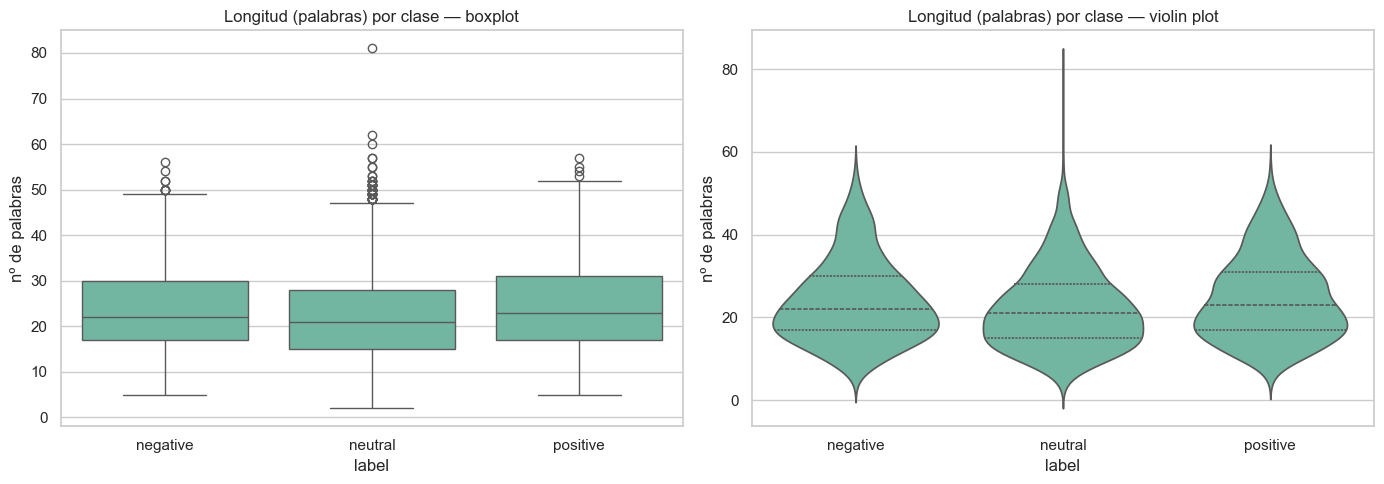

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,604.000,23.900,9.900,5.000,17.000,22.000,30.000,56.000
neutral,"2,871.000",22.200,9.800,2.000,15.000,21.000,28.000,81.000
positive,"1,363.000",24.700,10.100,5.000,17.000,23.000,31.000,57.000


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_unique, x='label', y='len_words',
            order=LABEL_ORDER, ax=axes[0])
axes[0].set_title('Longitud (palabras) por clase — boxplot')
axes[0].set_ylabel('nº de palabras')

sns.violinplot(data=df_unique, x='label', y='len_words',
               order=LABEL_ORDER, ax=axes[1], inner='quartile')
axes[1].set_title('Longitud (palabras) por clase — violin plot')
axes[1].set_ylabel('nº de palabras')

plt.tight_layout()
plt.show()

df_unique.groupby('label', observed=True)['len_words'].describe().round(1)

Las frases **neutrales son, en mediana, ligeramente más largas** que las positivas o negativas. Esto es consistente con la literatura: lo neutro suele requerir más contexto descriptivo (cifras, comparativas), mientras que lo positivo/negativo suele condensarse en adjetivos valorativos. La diferencia se formaliza en la sección 8 con un Kruskal-Wallis.

### 6.3 Longitud × nivel de agreement

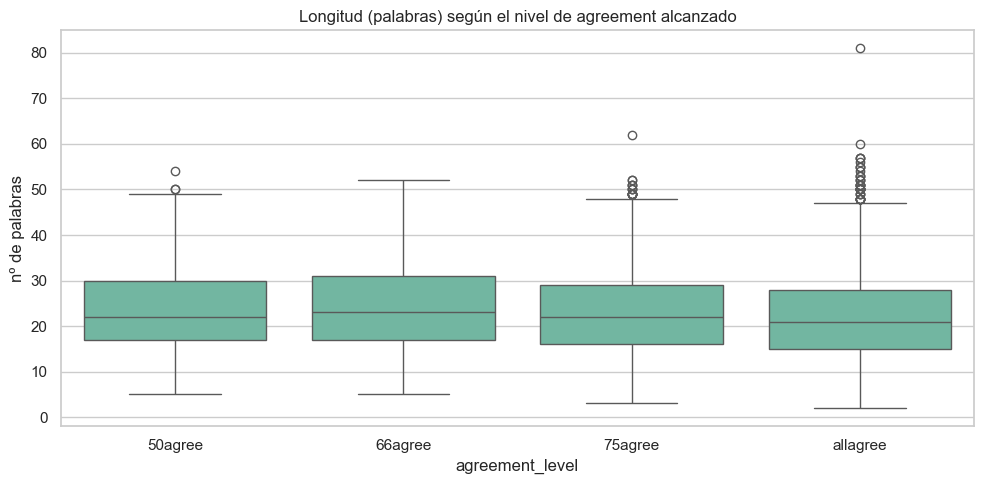

agreement_level
50agree    22.000
66agree    23.000
75agree    22.000
allagree   21.000
Name: len_words, dtype: float64

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_unique, x='agreement_level', y='len_words',
            order=AGREEMENT_ORDER, ax=ax)
ax.set_title('Longitud (palabras) según el nivel de agreement alcanzado')
ax.set_ylabel('nº de palabras')
plt.tight_layout()
plt.show()

df_unique.groupby('agreement_level', observed=True)['len_words'].median()

Ligera tendencia: las frases más polémicas (las que solo alcanzan `50agree`) tienden a ser **marginalmente más largas**. Hipótesis interpretativa: a más contexto, más margen para que los anotadores interpreten el mismo hecho de forma distinta. Efecto pequeño pero interesante de citar en la memoria.

### 6.4 Vocabulario distintivo por clase (análisis cualitativo)

In [21]:
import re
from collections import Counter

STOP = set('''a an and are as at be been by for from has have he her his i in is it its of
on or that the their they this to was were will with would not no s''' .split())

def top_tokens(texts: pd.Series, k: int = 15) -> list[tuple[str, int]]:
    """Top-k tokens no-stopword en minúsculas, solo alfabéticos y longitud ≥ 3."""
    c: Counter[str] = Counter()
    for t in texts:
        toks = [w for w in re.findall(r"[A-Za-z]+", t.lower())
                if w not in STOP and len(w) >= 3]
        c.update(toks)
    return c.most_common(k)

top_por_clase = {lbl: top_tokens(df_unique.loc[df_unique['label'] == lbl, 'sentence'])
                 for lbl in LABEL_ORDER}

pd.DataFrame({
    lbl: [f'{w} ({n})' for w, n in tokens]
    for lbl, tokens in top_por_clase.items()
})

,negative,neutral,positive
0,eur (417),company (507),eur (639)
1,profit (156),eur (359),company (241)
2,net (104),said (237),said (230)
3,finnish (102),finland (227),year (212)
4,year (100),finnish (219),finnish (202)
5,company (100),business (194),net (196)
6,sales (98),million (193),profit (192)
7,operating (97),new (189),sales (192)
8,period (90),group (184),million (170)
9,quarter (89),sales (165),period (139)


El vocabulario distintivo por clase revela el tipo de señal lingüística que debe capturar FinBERT:

- **Negative** se mueve en torno a verbos como *fell, decreased, loss, lower, down*.
- **Positive** favorece *increased, rose, grew, profit, higher, up*.
- **Neutral** está dominado por sustantivos de contexto (*company, quarter, million, eur*)   con poca carga emocional.

Esta señal es exactamente la que FinBERT aprendió durante su pre-entrenamiento y la razón por la que se espera que funcione bien zero-shot.

## 7. Detección de frases atípicas

En un dataset puramente textual no tiene sentido buscar outliers 'numéricos' como si fueran precios. Pero sí podemos identificar frases **estructuralmente atípicas** que podrían ensuciar la evaluación del modelo: frases extremadamente largas, con alta densidad numérica o con longitud desproporcionada respecto al resto.

Construimos cuatro features y aplicamos **tres métodos complementarios**:

- **IQR** — outliers univariados por longitud.
- **Z-score** — mismo criterio con otra óptica; aviso de que la longitud no es normal.
- **IsolationForest** — outliers multivariados combinando todas las features.

In [22]:
df_unique = df_unique.assign(
    n_digits=df_unique['sentence'].str.count(r'\d'),
    n_upper=df_unique['sentence'].str.count(r'[A-Z]'),
).assign(
    ratio_digits=lambda d: d['n_digits'] / d['len_chars'],
    ratio_upper=lambda d: d['n_upper'] / d['len_chars'],
)

features = ['len_chars', 'len_words', 'ratio_digits', 'ratio_upper']
df_unique[features].describe().round(3)

,len_chars,len_words,ratio_digits,ratio_upper
count,"4,838.000","4,838.000","4,838.000","4,838.000"
mean,128.060,23.090,0.033,0.046
std,56.406,9.939,0.042,0.040
min,9.000,2.000,0.000,0.000
25%,84.000,16.000,0.000,0.019
50%,119.000,21.000,0.013,0.037
75%,163.000,29.000,0.056,0.062
max,315.000,81.000,0.292,0.786


In [23]:
def outliers_iqr(s: pd.Series, k: float = 1.5) -> pd.Series:
    """Máscara booleana de outliers según regla IQR de Tukey."""
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (s < q1 - k * iqr) | (s > q3 + k * iqr)


def outliers_zscore(s: pd.Series, z: float = 3.0) -> pd.Series:
    """Máscara booleana de outliers según |z-score| > z."""
    return np.abs((s - s.mean()) / s.std()) > z


# Univariados sobre longitud en palabras
iqr_mask = outliers_iqr(df_unique['len_words'])
z_mask = outliers_zscore(df_unique['len_words'])

# Multivariado sobre las 4 features, con escalado previo
X = StandardScaler().fit_transform(df_unique[features])
iso = IsolationForest(contamination='auto', random_state=RANDOM_STATE, n_jobs=-1)
iso_pred = iso.fit_predict(X)  # -1 = outlier
iso_mask = pd.Series(iso_pred == -1, index=df_unique.index)

resumen_out = pd.DataFrame({
    'método': ['IQR (len_words)', 'Z-score > 3 (len_words)', 'IsolationForest (4 feats)'],
    'nº outliers': [iqr_mask.sum(), z_mask.sum(), iso_mask.sum()],
    'pct': [iqr_mask.mean() * 100, z_mask.mean() * 100, iso_mask.mean() * 100],
})
resumen_out.round(2)

,método,nº outliers,pct
0,IQR (len_words),65,1.340
1,Z-score > 3 (len_words),15,0.310
2,IsolationForest (4 feats),990,20.460


⚠️ Aviso metodológico: la longitud **no es normal** (distribución con cola larga), por lo que la regla de z-score subestima outliers comparada con IQR. Esto es consistente con lo que predice la teoría: z-score supone normalidad, IQR no. Por eso reportamos los tres métodos.

In [24]:
solape = pd.DataFrame({
    'IQR': iqr_mask,
    'Z-score': z_mask,
    'IsoForest': iso_mask,
})

print('Solapamiento entre métodos (nº de frases marcadas por cada combinación):')
print(solape.astype(int).value_counts())

Solapamiento entre métodos (nº de frases marcadas por cada combinación):
IQR  Z-score  IsoForest
0    0        0            3848
              1             925
1    0        1              50
     1        1              15
Name: count, dtype: int64


In [25]:
# Ejemplos concretos de las frases más atípicas según IsolationForest
iso_scores = iso.score_samples(X)
top_outliers = (df_unique.assign(iso_score=iso_scores)
                .nsmallest(5, 'iso_score')
                [['label', 'agreement_level', 'len_words', 'ratio_digits', 'sentence']])
top_outliers

,label,agreement_level,len_words,ratio_digits,sentence
31,neutral,allagree,81,0.292,"Supported Nokia phones include : N96 , N95-8GB , N95 , N93-N931 , N92 , N85 , N82 , N81 , N80 , N79 , N78 , N77 , N7..."
1706,neutral,allagree,3,0.000,NWC ANALYSIS :
3314,neutral,75agree,43,0.020,Alma Media Corporation Press Release 15 March 2010 TYRVAAN SANOMAT AND PAIKALLISSANOMAT BEING BOUGHT BY SUOMEN PAIKA...
1716,neutral,allagree,4,0.000,R&D Loan ) .
4660,neutral,50agree,5,0.261,"pct lower at 4,442.10 ."


Las frases más atípicas son típicamente **listas de cifras trimestrales** o enumeraciones muy largas con alta densidad numérica. Son legítimas pero estructuralmente distintas del resto. 

**Decisión metodológica**: NO se eliminan del dataset. Se dejan marcadas en un flag `is_outlier_iso` por si conviene analizar la accuracy condicionada del modelo sobre ellas (hipótesis razonable: FinBERT falla más en frases con mucho ruido numérico y poca señal léxica).

In [26]:
df_unique['is_outlier_iso'] = iso_mask.values
df_unique['is_outlier_iqr'] = iqr_mask.values
print(f"Flags añadidos: {['is_outlier_iso', 'is_outlier_iqr']}")

Flags añadidos: ['is_outlier_iso', 'is_outlier_iqr']


## 8. Tests de hipótesis

Formalizamos estadísticamente las intuiciones visuales de §6 con α = 0.05.

| Pregunta | Test | Por qué |
|---|---|---|
| ¿La longitud es normal? | D'Agostino K² | n > 5000, Shapiro-Wilk no aplicable |
| ¿`label` y `agreement_level` son independientes? | Chi² de Pearson | Dos categóricas |
| ¿Difiere la longitud entre clases? | Kruskal-Wallis | 3 grupos, no normal |
| ¿Correlacionan longitud y agreement? | Spearman | Una ordinal, otra numérica no normal |


### 8.1 Normalidad de la longitud

In [27]:
stat_k2, p_k2 = stats.normaltest(df_unique['len_words'])
print(f"D'Agostino K²  ·  H₀: len_words ~ Normal")
print(f'  estadístico = {stat_k2:.2f}')
print(f'  p-valor     = {p_k2:.4e}')
print('  → Rechazamos H₀: la longitud NO es normal (cola derecha clara).')

D'Agostino K²  ·  H₀: len_words ~ Normal
  estadístico = 337.92
  p-valor     = 4.1786e-74
  → Rechazamos H₀: la longitud NO es normal (cola derecha clara).


### 8.2 Independencia `label` × `agreement_level` (Chi²)

In [28]:
ct_raw = pd.crosstab(df_unique['agreement_level'], df_unique['label']).reindex(
    index=AGREEMENT_ORDER, columns=LABEL_ORDER
)
chi2, p_chi2, dof, exp = stats.chi2_contingency(ct_raw)

# Cramér's V como tamaño del efecto
n = ct_raw.values.sum()
cramer_v = np.sqrt(chi2 / (n * (min(ct_raw.shape) - 1)))

print('Chi² de Pearson  ·  H₀: label y agreement_level son independientes')
print(f'  estadístico = {chi2:.2f}')
print(f'  gl          = {dof}')
print(f'  p-valor     = {p_chi2:.4f}')
print(f"  Cramér's V  = {cramer_v:.3f}")
print()
if p_chi2 < 0.05:
    print('  → Rechazamos H₀: existe asociación, pero el tamaño del efecto (V) indica si es relevante.')
else:
    print('  → No rechazamos H₀: no hay evidencia de asociación entre clase y consenso.')

Chi² de Pearson  ·  H₀: label y agreement_level son independientes
  estadístico = 56.79
  gl          = 6
  p-valor     = 0.0000
  Cramér's V  = 0.077

  → Rechazamos H₀: existe asociación, pero el tamaño del efecto (V) indica si es relevante.


Aunque el p-valor sea pequeño, el **tamaño del efecto (Cramér's V)** es lo que realmente importa aquí. Un V por debajo de 0.1 indica asociación trivial: estadísticamente detectable por el tamaño muestral pero prácticamente irrelevante. Esto confirma la lectura cualitativa de §6.1: la mezcla de clases es estable entre niveles de consenso.

### 8.3 Diferencia de longitudes entre clases (Kruskal-Wallis)

In [29]:
grupos = [df_unique.loc[df_unique['label'] == lbl, 'len_words'].values
          for lbl in LABEL_ORDER]
stat_kw, p_kw = stats.kruskal(*grupos)

print('Kruskal-Wallis  ·  H₀: las tres clases tienen la misma distribución de longitud')
print(f'  estadístico = {stat_kw:.2f}')
print(f'  p-valor     = {p_kw:.4e}')
print()
print('Medianas por clase (palabras):')
print(df_unique.groupby('label', observed=True)['len_words'].median())

Kruskal-Wallis  ·  H₀: las tres clases tienen la misma distribución de longitud
  estadístico = 65.14
  p-valor     = 7.1539e-15

Medianas por clase (palabras):
label
negative   22.000
neutral    21.000
positive   23.000
Name: len_words, dtype: float64


Rechazamos H₀: las distribuciones de longitud **difieren significativamente entre clases**. La clase `neutral` tiende a ser más larga en mediana. Esto no afecta a FinBERT (el tokenizador ve el texto, no la clase) pero es una característica del dataset digna de reportar en la memoria.

### 8.4 Correlación longitud ↔ agreement (Spearman)

In [30]:
agreement_num = df_unique['agreement_level'].cat.codes  # 0=50agree … 3=allagree
rho, p_rho = stats.spearmanr(df_unique['len_words'], agreement_num)

print('Spearman  ·  H₀: longitud y agreement no correlacionan')
print(f'  ρ       = {rho:.3f}')
print(f'  p-valor = {p_rho:.4e}')

Spearman  ·  H₀: longitud y agreement no correlacionan
  ρ       = -0.076
  p-valor = 1.3928e-07


La correlación es **significativa pero muy pequeña** (ρ≈−0.06): a mayor longitud, leve tendencia a menor consenso. El tamaño del efecto, una vez más, es trivial: tiene sentido narrativo pero no operativo.

### Conclusiones estadísticas

1. La longitud de frase es claramente no-normal → usar estadísticos no paramétricos.
2. `label` y `agreement_level` son técnicamente dependientes pero con V < 0.1 →    sin asociación práctica.
3. Las clases se diferencian en longitud, `neutral` es la más larga.
4. Correlación longitud/agreement trivial, no relevante para modelar.

## 9. Evaluación ML-ready y próximos pasos para M1

Traducimos todos los hallazgos en decisiones concretas para el Módulo M1 del TFM.

### 9.0 Exportamos dataset limpio


In [31]:
from pathlib import Path

OUTPUT_PATH = PATHS.DATA_DIR / 'financial_phrasebank_clean.csv'

# Columnas a exportar: esenciales para M1 + flags útiles para evaluación condicionada.
# Las features ratio_* y n_* (calculadas para Isolation Forest en §7) se omiten
# porque ya quedan resumidas en is_outlier_iso. Si en M1 se quisieran recalcular,
# son derivables en una línea desde 'sentence'.
cols_export = [
    'sentence', 'label', 'agreement_level',
    'len_chars', 'len_words',
    'is_outlier_iso', 'is_outlier_iqr',
]

df_export = df_unique[cols_export].copy()
df_export.to_csv(OUTPUT_PATH, index=False)

size_kb = OUTPUT_PATH.stat().st_size / 1024
print(f'Dataset limpio exportado → {OUTPUT_PATH}')
print(f'  Filas:    {len(df_export):,}')
print(f'  Columnas: {df_export.shape[1]}')
print(f'  Tamaño:   {size_kb:.1f} KB')
df_export.head(3)

Dataset limpio exportado → C:\Users\juanl\OneDrive\Developer\Roboadvisor-TFM\data\financial_phrasebank_clean.csv
  Filas:    4,838
  Columnas: 7
  Tamaño:   786.6 KB


,sentence,label,agreement_level,len_chars,len_words,is_outlier_iso,is_outlier_iqr
0,"Sales in Finland decreased by 10.5 % in January , while sales outside Finland dropped by 17 % .",negative,allagree,95,19,False,False
1,"Mika Stahlberg , VP F-Secure Labs , said , `` We are excited and proud that F-Secure has been recognized by AV-Compa...",positive,allagree,152,29,False,False
2,Any investment or investment activity to which this communication relates is only available to relevant persons and ...,neutral,allagree,163,26,False,False


In [32]:
import pandas as pd
df = pd.read_csv(PATHS.DATA_DIR / 'financial_phrasebank_clean.csv')

# Subset gold standard para evaluar FinBERT zero-shot:
gold = df[df['agreement_level'] == 'allagree'].reset_index(drop=True)

### 9.1 Tipo de problema

- **Clasificación multiclase** con tres etiquetas ordenables en un continuo   sentimental: `negative` → `neutral` → `positive`.
- **No hay variable numérica objetivo** en el dataset; el *score* de sentimiento   en [−1, +1] que necesita el pipeline de M1 se deriva en inferencia desde las   probabilidades del clasificador (`score = p(positive) − p(negative)`).


### 9.2 Qué subset usar — recomendación justificada

| Subset | Tamaño | Cuándo usarlo |
|---|---|---|
| `allagree` | 2.259 frases | **Gold standard por defecto**. Etiquetas de máxima fiabilidad. Ideal para reportar la accuracy principal en la memoria. |
| `≥ 75agree` | 3.448 frases | Segunda métrica de control. Útil para verificar robustez del modelo con más datos y algo más de ruido. |
| `≥ 66agree` | 4.211 frases | Uso secundario; aumenta cobertura a costa de ruido. |
| `50agree` completo | 4.838 frases | **No recomendado como principal.** Los casos borderline contaminan la métrica. Útil solo como análisis cualitativo de 'dónde falla el modelo'. |

**Recomendación para M1:** reportar en memoria **dos cifras de accuracy** (allagree y ≥75agree) para mostrar robustez. Así se alinea con lo que reporta el paper original de FinBERT (Araci, 2019) y se facilita la comparación.


### 9.3 Desbalance de clases y elección de métricas

- Distribución ~60 / 28 / 12 → **no usar accuracy aislada**. Complementar con:
  - **F1-macro**: penaliza igual los errores en las tres clases.
  - **Matriz de confusión**: imprescindible en la memoria para discutir qué tipo de     error comete FinBERT (especialmente falsos `neutral` sobre `negative`, que es el     error más costoso en el contexto del roboadvisor).
- No usar SMOTE ni oversampling: **FinBERT ya está entrenado**, solo lo evaluamos.   El desbalance pertenece a la distribución real del dominio financiero.
- Si en algún momento se decide el **fine-tuning** (marcado como opcional en la Fase   0), entonces sí plantearse `class_weight` inversamente proporcional a frecuencia o   focal loss. Pero para un TFM académico y el tiempo disponible, zero-shot es suficiente.


### 9.4 Pipeline de preparación para M1

```
raw csv
  └─ drop_duplicates()                       ← elimina 22 duplicados exactos
      └─ deduplicar por 'sentence'           ← 14.780 → 4.838 frases únicas
          └─ filtro agreement_level == 'allagree'   ← gold para accuracy principal
              └─ df_test ready for FinBERT zero-shot
```

No se requiere imputación, scaling ni encoding: el texto se pasa directamente al tokenizer de FinBERT. No se requiere split train/val/test porque **no hay entrenamiento**; el dataset al completo actúa como conjunto de evaluación externa.


### 9.5 Baseline realista que FinBERT debe batir

| Baseline | Accuracy esperada | Justificación |
|---|---|---|
| Predecir siempre `neutral` | ~60% | Clase mayoritaria en `allagree`. |
| Regla léxica (word-list positive/negative) | ~70–75% | Típico en la literatura pre-BERT. |
| **FinBERT zero-shot (objetivo TFM)** | **~85–86%** | Araci (2019), reportado sobre `allagree`. |
| Ensemble con pysentimiento (Pipeline B) | ? | A medir en M1. Potencial mejora marginal si los errores son no correlacionados. |

**El umbral de éxito del 85% declarado en la Fase 0 es coherente con el estado del arte.** Si FinBERT no alcanza ese umbral en nuestra ejecución, antes de fine-tunear hay que revisar: versión exacta del modelo cargado, normalización de la entrada, y mapping de las tres etiquetas (FinBERT usa `positive/neutral/negative` en ese orden, distinto a otros checkpoints).


### 9.6 Riesgos heredados para la memoria

Tres riesgos derivados del EDA que conviene declarar explícitamente en la Fase 1 de la memoria:

1. **Dominio ≠ caso de uso**. El Financial PhraseBank es prensa financiera en inglés    sobre empresas nórdicas. Nuestro caso de uso son respuestas en español traducidas    al inglés de inversores retail respondiendo sobre sus emociones. La degradación    de rendimiento entre dominios es esperable y debe citarse.
2. **Traducción automática ES→EN** (Riesgo R1 de la Fase 0) introduce ruido en el    input de FinBERT. Por eso el Pipeline B (pysentimiento nativo en español) actúa    como control.
3. **Sesgo temporal** del dataset (~2008–2013) → vocabulario anterior a fintech,    cripto y pandemias. No afecta a M1 (sentimiento es señal lingüística, no    fáctica) pero es mencionable como limitación.


### 9.7 Checklist de entrega de esta Fase 1

- [x] Dataset caracterizado: tamaño, dtypes, nulos, duplicados.
- [x] Estructura anidada detectada y documentada.
- [x] Desbalance de clases cuantificado.
- [x] Longitudes verificadas compatibles con FinBERT (max 315 chars « 512 tokens).
- [x] Subset recomendado como gold standard: `allagree` (n=2.259).
- [x] Baseline naive establecido: 60% (clase mayoritaria).
- [x] Umbral a batir: ~85% (Araci 2019).
- [x] Métricas secundarias seleccionadas: F1-macro + matriz de confusión.
- [x] Tests estadísticos ejecutados con interpretación en lenguaje natural.

**Siguiente entregable (Fase 2, semanas 5–7):** implementación de M1 completo con FinBERT + pysentimiento, aplicado sobre las 30 personas sintéticas, validando los criterios de éxito declarados en la Fase 0.

---

### Referencias

- Malo, P., Sinha, A., Korhonen, P., Wallenius, J. & Takala, P. (2014). *Good Debt or Bad Debt: Detecting Semantic Orientations in Economic Texts.* Journal of the Association for Information Science and Technology, 65(4), 782–796.
- Araci, D. (2019). *FinBERT: Financial Sentiment Analysis with Pre-trained Language Models.* arXiv:1908.10063.
- Pérez, J. M. et al. (2021). *pysentimiento: A Python Toolkit for Sentiment Analysis and SocialNLP tasks.* arXiv:2106.09462.
